Inisialisasi Library yang Akan digunakan Selama Program

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Menampilkan citra yang akan diolah

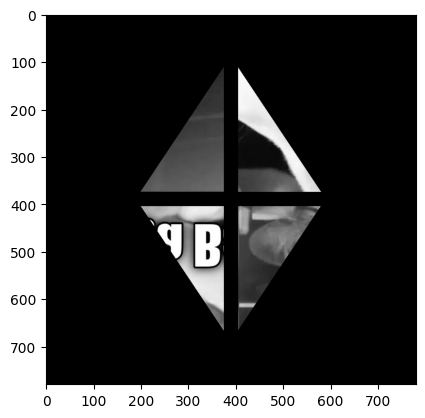

In [19]:
citra1 = cv.imread("Assets/citra1.png")

plt.imshow(citra1)

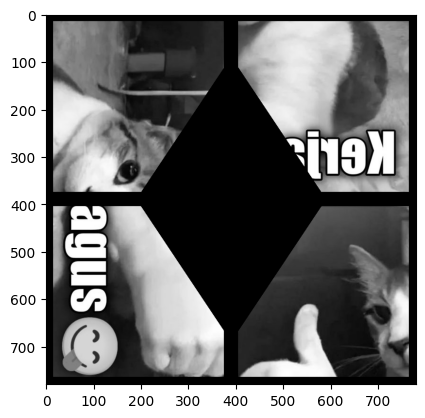

In [20]:
citra2 = cv.imread("Assets/citra2.png")

plt.imshow(citra2)

merubahcitra menjadi grayscale

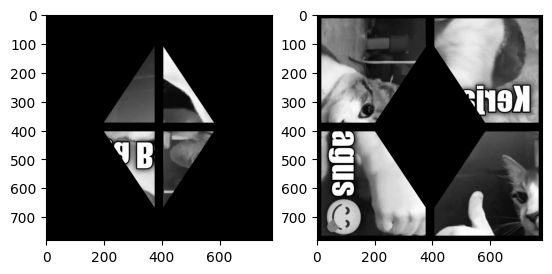

In [21]:
citra1 = plt.imread ('Assets/citra1.PNG')
citra2 = plt.imread ('Assets/citra2.PNG')

plt.subplot (1, 2, 1)
plt.imshow (citra1, cmap = "grey")

plt.subplot (1, 2, 2)
plt.imshow (citra2, cmap = "grey")

FUNCTION ROTASI
. h, w = image.shape[:2] - Menganbil ukuran gambar, h (height) dan w (width)
. val = int(val) % 360 - Normalisasi sudut supaya nilai rotasi selalu 0, 90, 180, atau 270
. if val == 0: - untuk rotasi 0°
. (i, j) → (j, h-1-i)- Rotasi 90°
. (i, j) → (h-1-i, w-1-j)- Rotasi 180°
. (i, j) → (w-1-j, i)- Rotasi 270°


In [22]:
def fungsi_empat_R(image, val):
    h, w = image.shape[:2]
    val = int(val) % 360
    if image.ndim == 3:
        c = image.shape[2]
    else:
        c = None

    if val == 0:
        return image

    elif val == 90:
        if c:
            rot = np.zeros((w, h, c), dtype=image.dtype)
            for i in range(h):
                for j in range(w):
                    rot[j, h-1-i] = image[i, j]
        else:
            rot = np.zeros((w, h), dtype=image.dtype)
            for i in range(h):
                for j in range(w):
                    rot[j, h-1-i] = image[i, j]
        return rot

    elif val == 180:
        rot = np.zeros_like(image)
        for i in range(h):
            for j in range(w):
                rot[h-1-i, w-1-j] = image[i, j]
        return rot

    elif val == 270:
        if c:
            rot = np.zeros((w, h, c), dtype=image.dtype)
            for i in range(h):
                for j in range(w):
                    rot[w-1-j, i] = image[i, j]
        else:
            rot = np.zeros((w, h), dtype=image.dtype)
            for i in range(h):
                for j in range(w):
                    rot[w-1-j, i] = image[i, j]
        return rot

    return image

Melakukan rotasi pada citra1

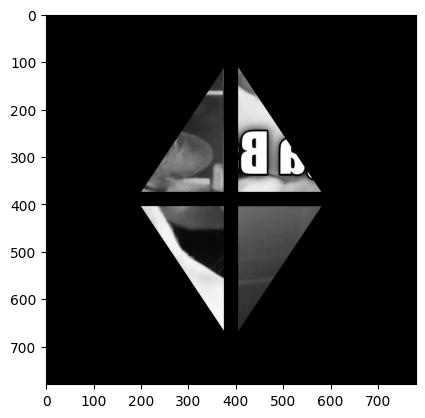

In [23]:
rotasi = fungsi_empat_R(citra1, 180)
plt.imshow(rotasi, cmap='gray')

Function Gabung
digunakan untuk menambahkan 2 citra dengan ukuran yang sama 

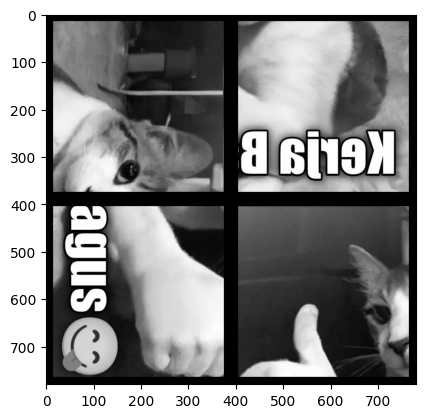

In [24]:
def fungsi_dua_a(rotasi,citra2):
    return rotasi + citra2
merge = fungsi_dua_a(rotasi, citra2)
plt.imshow(merge, cmap='gray')

Function Split
Digunakan untuk membagi citra menjadi 4 bagian
 
. h, w = image.shape[:2]- mengambil ukuran gambar h (height) dan w (width)
. h2 = h // 2w2 = w // 2 - menentukan titik tengah
. Membagi jadi 4 bagian
bagian1 = image[0:h2, 0:w2] - dari atas sampai tengah, kiri sampai tengah
bagian2 = image[0:h2, w2:w] - dari atas sampai tengah, tengah ke kanan
bagian3 = image[h2:h, 0:w2] - dari tengah ke bawah, kiri sampai tengah
bagian4 = image[h2:h, w2:w] - dari tengah ke bawah, tengah ke kanan
. return bagian1, bagian2, bagian3, bagian4 - Mengembalikan 4 potongan citra sekaligus

In [25]:
def bagi(image):
    h, w = image.shape[:2]
    h2 = h // 2
    w2 = w // 2
    bagian1 = image[0:h2, 0:w2]    
    bagian2 = image[0:h2, w2:w]     
    bagian3 = image[h2:h, 0:w2]    
    bagian4 = image[h2:h, w2:w]    

    return bagian1, bagian2, bagian3, bagian4

Menampilkan hasil citra yang sudah dibagi

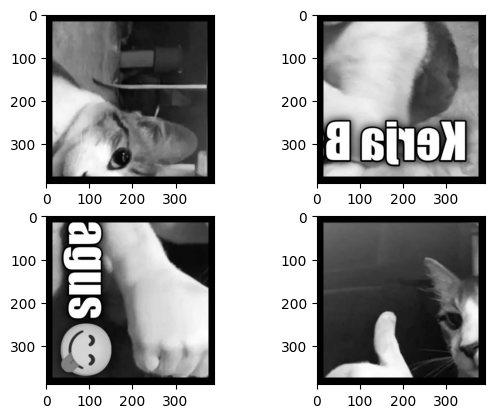

In [26]:
b1, b2, b3, b4 = bagi(merge)

plt.subplot(2,2,1)
plt.imshow(b1, cmap='gray')

plt.subplot(2,2,2)
plt.imshow(b2, cmap='gray')

plt.subplot(2,2,3)
plt.imshow(b3, cmap='gray')

plt.subplot(2,2,4)
plt.imshow(b4, cmap='gray')

plt.show()

Meelakukan rotasi pada b1

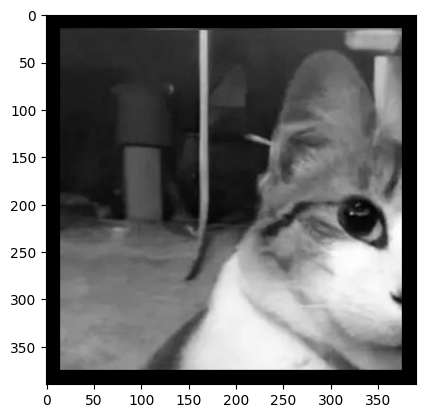

In [27]:
foto1 = fungsi_empat_R(b1, 270)
plt.imshow(foto1, cmap='gray')

Function Flip
Digunakan untuk membalik citra secara horizontal maupun vertical.Fungsi
. def fungsi_satu(image, mode='X'): - Menerima citra dan arah flip ('X' atau 'Y')
. h, w = image.shape[:2]- mengambil ukuran gambar
. for i in range(h):
    for j in range(w): - Mengakses setiap piksel (i, j)
. (i, j) → (i, w-1-j) - flip horizontal (mode 'X')
. (i, j) → (h-1-i, j) - flip vertikal (mode 'Y')
. foto2 = fungsi_satu(b2, 'x') - Membalik gambar b2 secara horizontal
. plt.imshow(foto2, cmap='gray') - Menampilkan gambar hasil flip

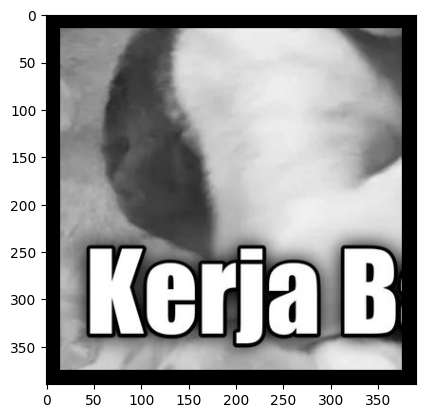

In [28]:
def fungsi_satu(image, mode='X'):
    h, w = image.shape[:2]

    if image.ndim == 3:
        c = image.shape[2]
        hasil = np.zeros((h, w, c), dtype=image.dtype)
    else:
        hasil = np.zeros((h, w), dtype=image.dtype)

    for i in range(h):
        for j in range(w):
            if mode.upper() == 'X':  
                hasil[i, j] = image[i, w - 1 - j]
            elif mode.upper() == 'Y':
                hasil[i, j] = image[h - 1 - i, j]

    return hasil
foto2 = fungsi_satu(b2, 'x')
plt.imshow(foto2, cmap='gray')


Melakukan rotasi pada b3

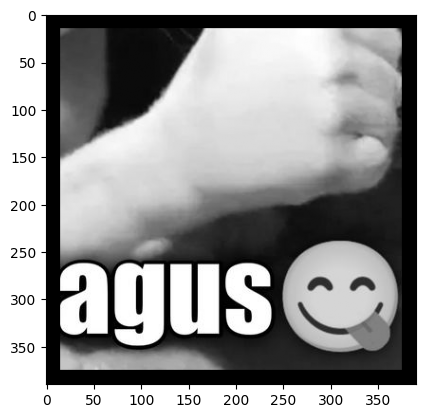

In [29]:
foto3 = fungsi_empat_R(b3, 270)
plt.imshow(foto3, cmap='gray')

Melakukan flip  horizontal pada b4

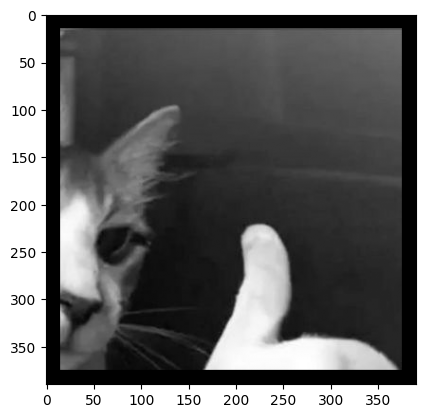

In [30]:

foto4 = fungsi_satu(b4, 'x')
plt.imshow(foto4, cmap='gray')


Fungsi untukm mengabungkan 4 citra
. h, w = f1.shape[:2] - mengambil ukuran
. f2 = cv.resize(f2, (w, h))
f3 = cv.resize(f3, (w, h))
f4 = cv.resize(f4, (w, h)) - untuk menyamakan ukuran citra
. atas = np.hstack((f1, f4)) - gabung baris atas
. bawah = np.hstack((f2, f3)) - gabung baris bawah
. hasil = np.vstack((atas, bawah)) - gabung baris atas dan baris bawah

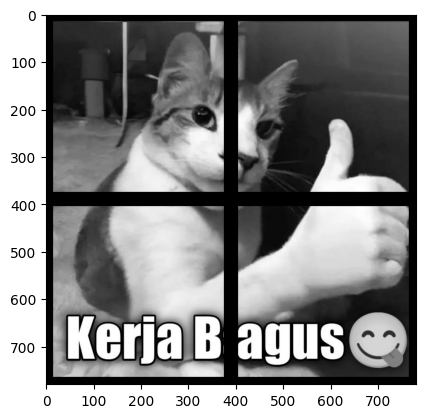

In [31]:
def rangkai_citra(f1, f2, f3, f4):
    h, w = f1.shape[:2]
    f2 = cv.resize(f2, (w, h))
    f3 = cv.resize(f3, (w, h))
    f4 = cv.resize(f4, (w, h))

    atas = np.hstack((f1, f4))    
    bawah = np.hstack((f2, f3)) 

    hasil = np.vstack((atas, bawah)) 
    return hasil

hasil = rangkai_citra(foto1, foto2, foto3, foto4)

plt.imshow(hasil, cmap='gray')
plt.show()

In [32]:
pembagian = hasil / 2

min_val = np.min(pembagian)
max_val = np.max(pembagian)
normalisasi = (pembagian - min_val) / (max_val - min_val) * 255

Menampilkan histogram sebelum dan sesudah normalisasi

Text(0, 0.5, 'Frekuensi')

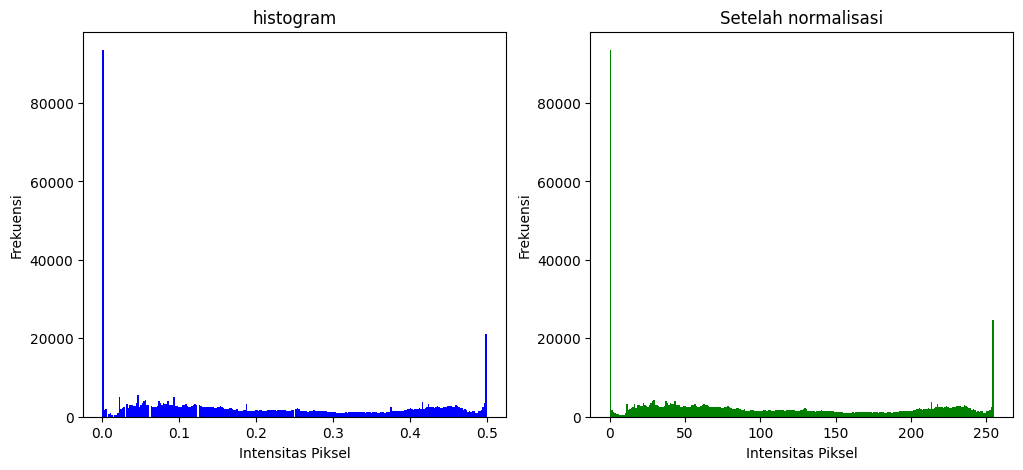

In [33]:
plt.figure(figsize=(12,5))


plt.subplot(1, 2, 1)
plt.hist(pembagian.ravel(), color="blue", bins=255)
plt.title("histogram")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")


plt.subplot(1, 2, 2)
plt.hist(normalisasi.ravel(), color="green", bins=255)
plt.title("Setelah normalisasi")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")

Konvolusi Citra dengan Zero Padding

proses konvolusi citra menggunakan kernel 4×4 dengan metode zero padding, kemudian hasil akhirnya dibatasi menggunakan clipping.

- `kernel = np.array(...) — Membuat matriks kernel berukuran 4×4 yang digunakan sebagai filter konvolusi.
- Nilai positif `4/10` pada bagian tengah berfungsi memperkuat area utama citra.
- Nilai negatif `-1/10` di bagian tepi berfungsi menonjolkan perbedaan intensitas di sekitar piksel.

- `h, w = normalisasi.shape` — Mengambil ukuran tinggi (`h`) dan lebar (`w`) dari citra `normalisasi`.

Zero Padding

- `pad = 2` — Menentukan ketebalan padding sebanyak 2 piksel di setiap sisi citra.
- `np.pad(normalisasi, pad, mode='constant', constant_values=0)` — Menambahkan bingkai bernilai 0 di sekeliling citra.

Padding nol bertujuan agar proses konvolusi tetap bisa dilakukan sampai bagian tepi gambar.

- `padded` — Menyimpan citra yang sudah ditambahkan padding nol.
Proses Konvolusi

- `output = np.zeros((h, w), dtype=float) — Membuat array kosong untuk menyimpan hasil konvolusi.

- Perulangan `for i` dan `for j` — Digunakan untuk menggeser kernel ke seluruh area citra.
- `region = padded[i:i+4, j:j+4]`** — Mengambil area citra berukuran 4×4 sesuai ukuran kernel.
- `region * kernel` — Mengalikan setiap elemen area citra dengan kernel.
- `np.sum(...)` — Menjumlahkan seluruh hasil perkalian dan menyimpannya ke piksel output.
Clipping Nilai Piksel

- `np.clip(output, 0, 255)` — Membatasi nilai piksel agar tetap berada pada rentang 0 sampai 255.
- Nilai kurang dari 0 diubah menjadi 0.
- Nilai lebih dari 255 diubah menjadi 255.

Text(0.5, 1.0, 'Hasil Konvolusi + Clipping')

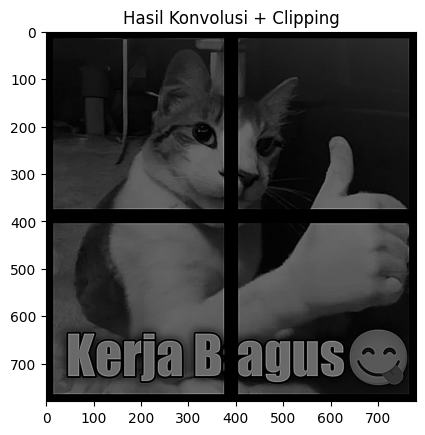

In [34]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

h, w = normalisasi.shape


pad = 2
padded = np.pad(normalisasi, pad, mode='constant', constant_values=0)

output = np.zeros((h, w), dtype=float)

for i in range(h):
    for j in range(w):
        region = padded[i:i+4, j:j+4]
        output[i, j] = np.sum(region * kernel)

kliping = np.clip(output, 0, 255)

plt.imshow(kliping, cmap='gray')
plt.title("Hasil Konvolusi + Clipping")

Menampilkan histogram hasil konvolusi dan clipping

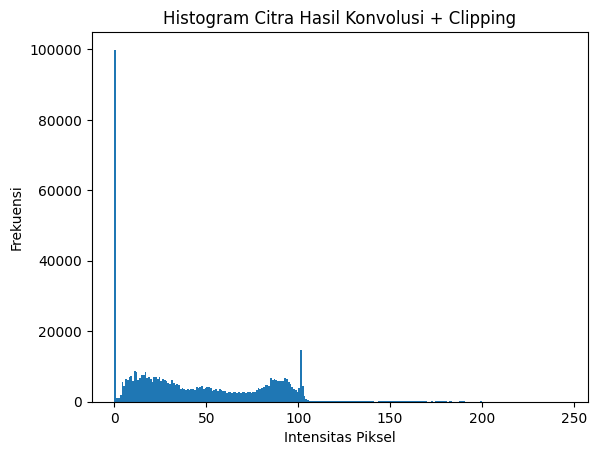

In [35]:
plt.hist(kliping.ravel(), bins=255)
plt.title("Histogram Citra Hasil Konvolusi + Clipping")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.show()